#### Belli Luigi - 2152859 - Advanced Topics of Physics of Data

# Data-Driven Discovery of Accretion Disk Hydrodynamics around Compact Objects

### Overview
Accretion disks around compact objects (Black Holes and Neutron Stars) are governed by viscous shear diffusion and angular momentum transport. In this project, I apply **Sparse Identification of Nonlinear Dynamics (SINDy)** and **Weak SINDy (WSINDy)** to discover the governing partial differential equation directly from numerical fluid simulations.

## Setup

In [1]:
import numpy as np
import scipy.signal as signal
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt
import pysindy as ps
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'figure.titlesize': 14,
    'lines.linewidth': 2,
    'figure.dpi': 120
})
np.random.seed(42)


## 1: Simulating Accretion Disk Hydrodynamics

The standard thin accretion disk diffusion equation governs the evolution of the surface mass density $\Sigma(R, t)$:

$$\frac{\partial \Sigma}{\partial t} = \frac{3}{R} \frac{\partial}{\partial R} \left[ \sqrt{R} \frac{\partial}{\partial R} \left( \nu \Sigma \sqrt{R} \right) \right]$$

where $\nu$ is the kinematic viscosity. Expanding the derivatives we get:
$$\frac{\partial \Sigma}{\partial t} = 3\nu \frac{\partial^2 \Sigma}{\partial R^2} + \frac{9\nu}{2R} \frac{\partial \Sigma}{\partial R}$$

Simulation consists in an initial Gaussian ring $\Sigma(R, 0) = \exp\left(-\frac{(R - R_0)^2}{2 w^2}\right)$ spreading around a compact object with innermost stable circular orbit $R_{\rm ISCO} = 6.0\,M$ .

In [2]:
def solve_accretion_disk(R_in=6.0, R_out=70.0, N_R=480, t_max=90.0, N_t=701, 
                         nu=0.15, R_0=25.0, width=3.0, is_black_hole=True):
    """
    solves the 1d thin disk viscous diffusion pde using a sub-stepped scheme, for more stability
    """
    R = np.linspace(R_in, R_out, N_R)
    dR = R[1] - R[0]
    t = np.linspace(0, t_max, N_t)
    dt = t[1] - t[0]
    
    Sigma = np.zeros((N_t, N_R))
    # initial gaussian ring
    Sigma[0, :] = np.exp(-0.5 * ((R - R_0) / width)**2)
    if is_black_hole:
        Sigma[0, 0] = 0.0  # isco mass sink
    Sigma[0, -1] = 0.0
    
    # sub-stepping 
    n_substeps = 20
    dt_sub = dt / n_substeps
    curr_Sigma = Sigma[0, :].copy()
    
    for n in range(0, N_t - 1):
        for _ in range(n_substeps):
            # conservative viscous flux: F = nu * Sigma * sqrt(R)
            flux = nu * curr_Sigma * np.sqrt(R)
            d_flux = np.gradient(flux, dR)
            inner_term = np.sqrt(R) * d_flux
            d_inner = np.gradient(inner_term, dR)
            dSigma_dt = (3.0 / R) * d_inner
            
            curr_Sigma += dt_sub * dSigma_dt
            if is_black_hole:
                curr_Sigma[0] = 0.0  # zero torque at isco
            else:
                curr_Sigma[0] = curr_Sigma[1]  # zero-gradient boundary layer pile-up for ns
            curr_Sigma[-1] = 0.0
            curr_Sigma = np.maximum(curr_Sigma, 0.0)
        Sigma[n+1, :] = curr_Sigma.copy()
        
    return R, t, Sigma

# generate simulation data
R_grid, t_grid, Sigma_data = solve_accretion_disk(nu=0.15, is_black_hole=True)
print(f"Simulation completed. Grid: {len(R_grid)} radial points x {len(t_grid)} time steps.")
print(f"Radial range: [{R_grid[0]}, {R_grid[-1]}] M | Time duration: [0, {t_grid[-1]}] M")

Simulation completed. Grid: 480 radial points x 701 time steps.
Radial range: [6.0, 70.0] M | Time duration: [0, 90.0] M


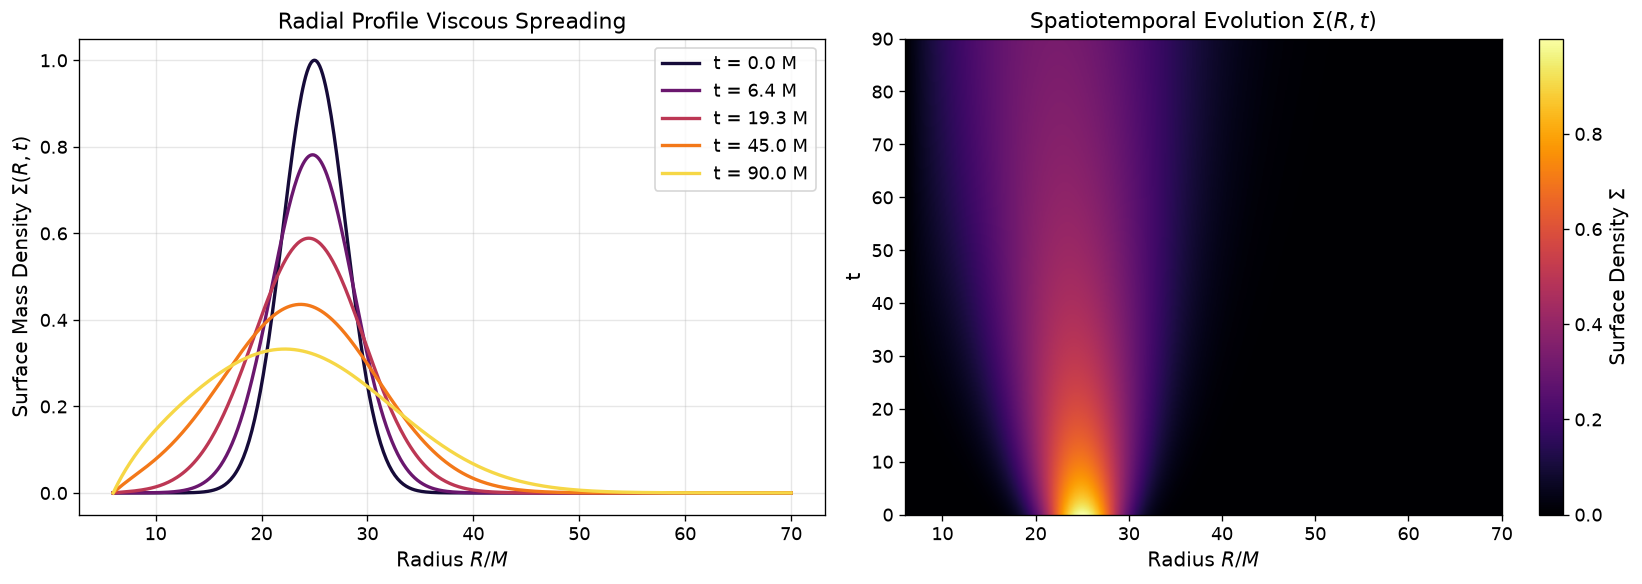

In [3]:
# visualize the viscous spreading of the accretion disk
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# radial density profiles over time
time_indices = [0, 50, 150, 350, 700]
colors = plt.cm.inferno(np.linspace(0.1, 0.9, len(time_indices)))
for idx, c in zip(time_indices, colors):
    ax1.plot(R_grid, Sigma_data[idx, :], label=f't = {t_grid[idx]:.1f} M', color=c, lw=2)
ax1.set_xlabel('Radius $R / M$')
ax1.set_ylabel('Surface Mass Density $\Sigma(R, t)$')
ax1.set_title('Radial Profile Viscous Spreading')
ax1.grid(True, alpha=0.3)
ax1.legend()

#spatiotemporal 2d heatmap
im = ax2.imshow(Sigma_data, aspect='auto', origin='lower', 
                extent=[R_grid[0], R_grid[-1], t_grid[0], t_grid[-1]],
                cmap='inferno')
ax2.set_xlabel('Radius $R / M$')
ax2.set_ylabel('t')
ax2.set_title('Spatiotemporal Evolution $\Sigma(R, t)$')
fig.colorbar(im, ax=ax2, label='Surface Density $\Sigma$')

plt.tight_layout()
plt.show()

## Step 2: PDE Discovery


1. **SINDy** evaluates pointwise derivatives $\frac{\partial \Sigma}{\partial t}$ and $\mathbf{\Theta}(\Sigma)$ using finite differences.
2. **WSINDy** convolves the PDE against compact smooth test functions $\psi(R, t)$ using integration by parts:
   $$\int_\Omega \frac{\partial\Sigma}{\partial t} \psi \, dR dt = -\int_\Omega \Sigma \frac{\partial \psi}{\partial t} \, dR dt$$
   This projects derivatives onto test functions, avoiding numerical differentiation noise.

I used default configuration to see what i can get out of the box

In [4]:
# reshape data: (n_spatial, n_time, n_channels)
u_pysindy = Sigma_data.T[:, :, np.newaxis] 

# sindy library
pde_lib_strong = ps.PDELibrary(
    derivative_order=2,
    spatial_grid=R_grid,
    include_bias=False
)
opt_strong = ps.STLSQ(threshold=0.1, alpha=0.05, max_iter=20,normalize_columns=True)
model_strong = ps.SINDy(feature_library=pde_lib_strong, optimizer=opt_strong)
model_strong.fit(u_pysindy, t=t_grid, feature_names=['Sigma'])

# wsindy library
R_mesh, t_mesh = np.meshgrid(R_grid, t_grid, indexing='ij')
spatiotemporal_grid = np.stack([R_mesh, t_mesh], axis=-1)

L_R = float(R_grid[-1] - R_grid[0])
L_t = float(t_grid[-1] - t_grid[0])
H_R = float(L_R / 20.0)
H_t = float(L_t / 20.0)

weak_lib = ps.WeakPDELibrary(
    derivative_order=2,
    spatiotemporal_grid=spatiotemporal_grid,
    K=1000,
    H_xt=[H_R, H_t],
    include_bias=False
)
opt_weak = ps.STLSQ(threshold=0.1, alpha=0.05, max_iter=20,normalize_columns=True)
model_weak = ps.SINDy(feature_library=weak_lib, optimizer=opt_weak)
model_weak.fit(u_pysindy, t=t_grid, feature_names=['Sigma'])

# print discovered equations
print("SINDy Discovered PDE:")
model_strong.print()
print("\nWSINDy Discovered PDE:")
model_weak.print()

SINDy Discovered PDE:
(Sigma)' =  0.003 Sigma + -0.006 Sigma^2 +  0.032 Sigma_1 +  0.420 Sigma_11 +  0.089 SigmaSigma_11 + -0.115 Sigma^3Sigma_11

WSINDy Discovered PDE:
(Sigma)' =  0.031 Sigma_1 +  0.458 Sigma_11


In [ ]:
w_feature_names = model_weak.get_feature_names()
w_coefficients = model_weak.coefficients()[0]  
w_coef_dict = dict(zip(w_feature_names, w_coefficients))

w_c_sigma11 = w_coef_dict.get('Sigma_11', 0.0)

feature_names = model_strong.get_feature_names()
coefficients = model_strong.coefficients()[0]  

coef_dict = dict(zip(feature_names, coefficients))

c_sigma11 = coef_dict.get('Sigma_11', 0.0)

print(f"Coefficient of (w) Sigma_11: {w_c_sigma11}, wnu = {w_c_sigma11/3}")
print(f"Coefficient of Sigma_11: {c_sigma11}, snu = {c_sigma11/3}")
print('Target: 0.45')
print(f'Relative errors: Sindy = {(np.abs(0.15-(c_sigma11/3))/0.15)*100:.4f}%, WSindy = {(np.abs(0.15-(w_c_sigma11/3))/0.15)*100:.4f}%')
print(f'Number of non-zero coefficients (target is 2): Sindy  = {np.count_nonzero(coefficients)}, WSindy {np.count_nonzero(w_coefficients)}')
print(f"FVU SINDy:  {1.0 - model_strong.score(u_pysindy, t=t_grid):.4e}")
print(f"FVU WSINDy: {1.0 - model_weak.score(u_pysindy, t=t_grid):.4e}")


Coefficient of (w) Sigma_11: 0.45789811281369375, wnu = 0.15263270427123124
Coefficient of Sigma_11: 0.4200079811571535, snu = 0.14000266038571782
Target: 0.45
Relative errors: Sindy = 6.6649%, WSindy = 1.7551%
Number of non-zero coefficients (target is 2): Sindy  = 6, WSindy 2
FVU SINDy:  1.7555e-02
FVU WSINDy: 8.6580e-03


Reconstruction Relative Error vs Ground Truth:
  • SINDy  (Step 2): 2.80%
  • WSINDy (Step 2): 4.98%


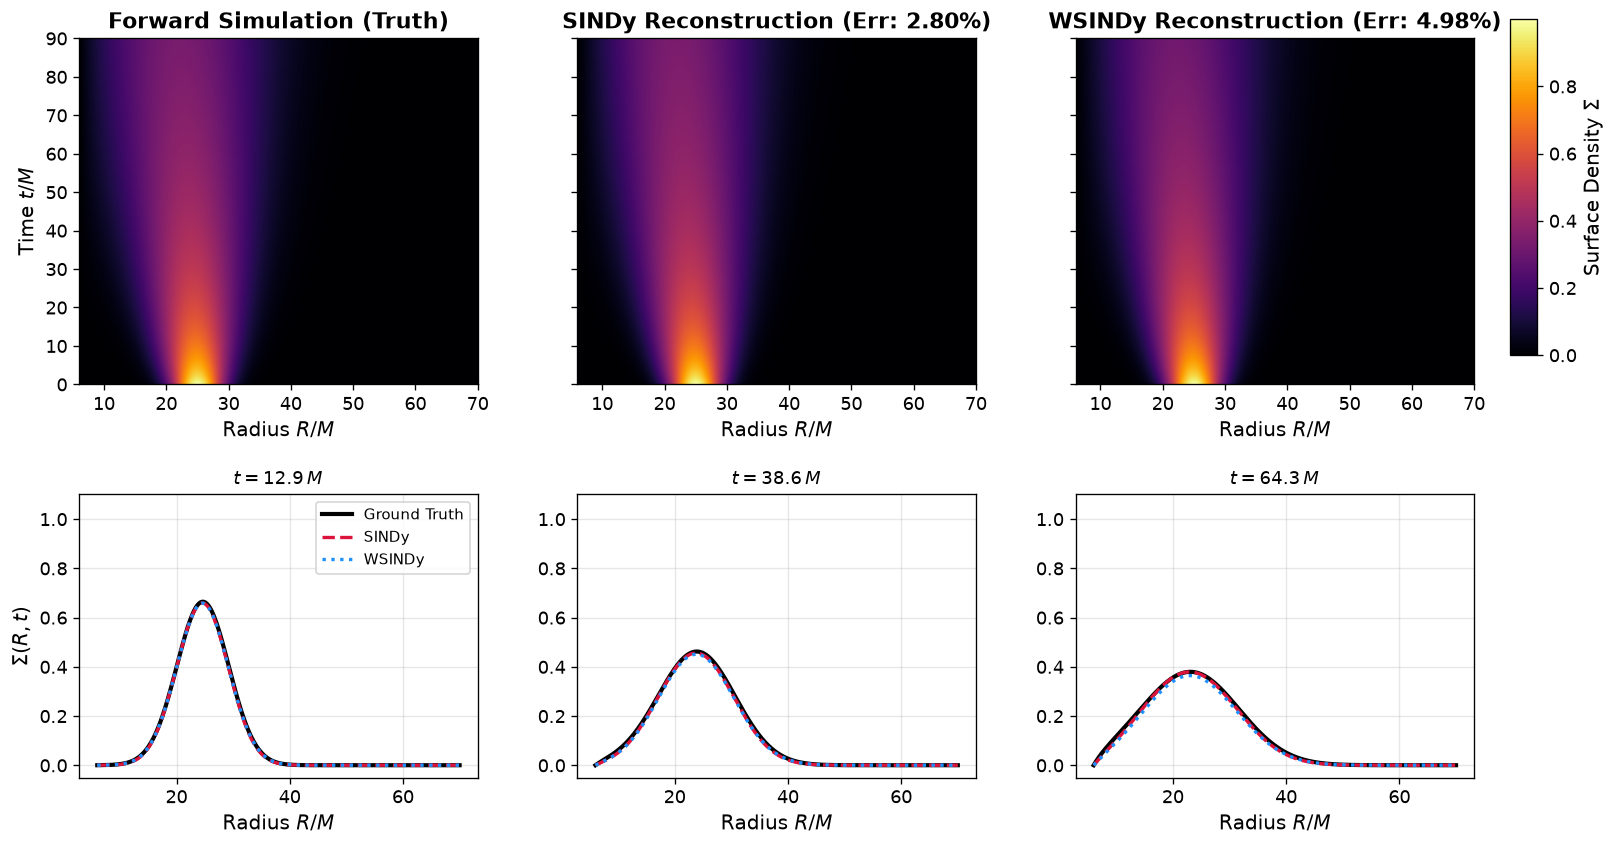

In [6]:
def simulate_discovered_pde(model, R_grid, t_grid, init_profile, n_substeps=40):
    names = model.get_feature_names()
    coeffs = model.coefficients()[0]
    coef_dict = dict(zip(names, coeffs))
    
    dR = R_grid[1] - R_grid[0]
    dt = t_grid[1] - t_grid[0]
    N_t = len(t_grid)
    N_R = len(R_grid)
    dt_sub = dt / n_substeps
    
    Sigma_sim = np.zeros((N_t, N_R))
    curr = init_profile.copy()
    Sigma_sim[0, :] = curr.copy()
    
    for n in range(N_t - 1):
        for _ in range(n_substeps):
            dSigma_dt = np.zeros_like(curr)
            for name, c in coef_dict.items():
                if abs(c) < 1e-5:
                    continue
                term_val = np.ones_like(curr)
                if 'Sigma_11' in name:
                    term_val *= np.gradient(np.gradient(curr, dR), dR)
                elif 'Sigma_1' in name:
                    term_val *= np.gradient(curr, dR)
                if 'Sigma^3' in name:
                    term_val *= curr**3
                elif 'Sigma^2' in name:
                    term_val *= curr**2
                elif name.startswith('Sigma') and not name.startswith('Sigma_') and ('Sigma^' not in name):
                    term_val *= curr
                dSigma_dt += c * term_val
                
            curr += dt_sub * dSigma_dt
            curr[0] = 0.0   # ISCO sink boundary (zero torque)
            curr[-1] = 0.0  # outer boundary
            curr = np.maximum(curr, 0.0)
            if np.any(np.isnan(curr)) or np.any(np.isinf(curr)):
                break
        Sigma_sim[n+1, :] = curr.copy()
    return Sigma_sim

init_profile = Sigma_data[0, :].copy()
Sigma_rec_sindy = simulate_discovered_pde(model_strong, R_grid, t_grid, init_profile)
Sigma_rec_wsindy = simulate_discovered_pde(model_weak, R_grid, t_grid, init_profile)

err_sindy = np.linalg.norm(Sigma_rec_sindy - Sigma_data) / np.linalg.norm(Sigma_data) * 100
err_wsindy = np.linalg.norm(Sigma_rec_wsindy - Sigma_data) / np.linalg.norm(Sigma_data) * 100

print(f"Reconstruction Relative Error vs Ground Truth:")
print(f"  • SINDy  (Step 2): {err_sindy:.2f}%")
print(f"  • WSINDy (Step 2): {err_wsindy:.2f}%")

fig = plt.figure(figsize=(15, 8))
gs = fig.add_gridspec(2, 3, height_ratios=[1.1, 0.9], hspace=0.35, wspace=0.25)
vmax = np.max(Sigma_data)

ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(Sigma_data, aspect='auto', origin='lower',
                 extent=[R_grid[0], R_grid[-1], t_grid[0], t_grid[-1]],
                 cmap='inferno', vmin=0, vmax=vmax)
ax0.set_title(r'Forward Simulation (Truth)', fontweight='bold')
ax0.set_xlabel(r'Radius $R / M$')
ax0.set_ylabel(r'Time $t / M$')

ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
ax1.imshow(Sigma_rec_sindy, aspect='auto', origin='lower',
           extent=[R_grid[0], R_grid[-1], t_grid[0], t_grid[-1]],
           cmap='inferno', vmin=0, vmax=vmax)
ax1.set_title(f'SINDy Reconstruction (Err: {err_sindy:.2f}%)', fontweight='bold')
ax1.set_xlabel(r'Radius $R / M$')
ax1.tick_params(labelleft=False)

ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)
ax2.imshow(Sigma_rec_wsindy, aspect='auto', origin='lower',
           extent=[R_grid[0], R_grid[-1], t_grid[0], t_grid[-1]],
           cmap='inferno', vmin=0, vmax=vmax)
ax2.set_title(f'WSINDy Reconstruction (Err: {err_wsindy:.2f}%)', fontweight='bold')
ax2.set_xlabel(r'Radius $R / M$')
ax2.tick_params(labelleft=False)

cbar_ax = fig.add_axes([0.92, 0.55, 0.015, 0.35])
fig.colorbar(im0, cax=cbar_ax, label=r'Surface Density $\Sigma$')

snapshots = [100, 300, 500, 700]
for col_idx, snap in enumerate(snapshots[:3]):
    ax_snap = fig.add_subplot(gs[1, col_idx])
    t_val = t_grid[snap]
    ax_snap.plot(R_grid, Sigma_data[snap, :], 'k-', lw=2.5, label='Ground Truth')
    ax_snap.plot(R_grid, Sigma_rec_sindy[snap, :], '--', color='crimson', lw=2.0, label='SINDy')
    ax_snap.plot(R_grid, Sigma_rec_wsindy[snap, :], ':', color='dodgerblue', lw=2.0, label='WSINDy')
    ax_snap.set_title(f'$t = {t_val:.1f}\\,M$', fontsize=11, fontweight='bold')
    ax_snap.set_xlabel(r'Radius $R / M$')
    if col_idx == 0:
        ax_snap.set_ylabel(r'$\Sigma(R, t)$')
        ax_snap.legend(fontsize=9, loc='upper right')
    ax_snap.grid(True, alpha=0.3)
    ax_snap.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()


## Step 3: Model Selection

I plotted model complexity over FVU, ranging the sparsity threshold $\lambda \in [10^{-3}, 10^{0.5}]$.

$$\text{FVU} = 1 - R^2 = \frac{\sum (\dot{\Sigma} - \hat{\dot{\Sigma}})^2}{\sum (\dot{\Sigma} - \bar{\dot{\Sigma}})^2}$$

(Numerator:total squared error between true time derivatives $\dot{\Sigma}$ and model predictions $\hat{\dot{\Sigma}}$.)

(Denominator: total variance of the true time derivatives around their average value $\bar{\dot{\Sigma}}$.)

($R^2$: explained variance fraction.)

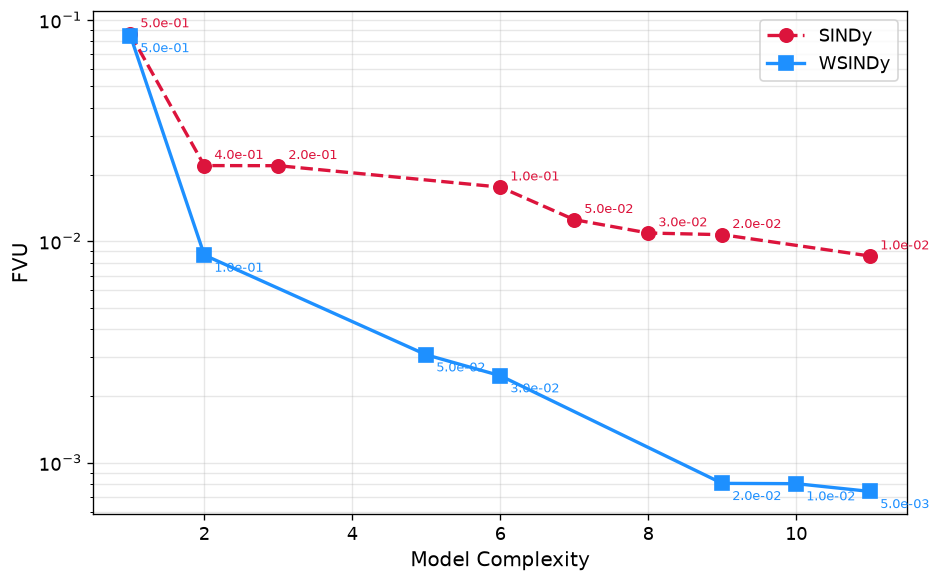

In [7]:
# threshold range
thresholds = [5e-1,4e-1,3e-1,2e-1,1e-1, 5e-2,4e-2,3e-2,2e-2, 1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
pareto_strong = {}
pareto_weak = {}

for th in thresholds:
    # sindy 
    opt_s = ps.STLSQ(threshold=th, alpha=0.05, max_iter=500, normalize_columns=True)
    m_s = ps.SINDy(feature_library=pde_lib_strong, optimizer=opt_s)
    m_s.fit(u_pysindy, t=t_grid, feature_names=['Sigma'])
    coeffs_s = m_s.coefficients()[0]
    k_s = int(np.sum(np.abs(coeffs_s) > 1e-4))
    r2_s = m_s.score(u_pysindy, t=t_grid)
    fvu_s = max(1.0 - r2_s, 1e-8)
    if k_s not in pareto_strong or fvu_s < pareto_strong[k_s]['fvu']:
        pareto_strong[k_s] = {'fvu': fvu_s, 'coeffs': coeffs_s, 'names': m_s.get_feature_names(), 'th': th}
    
    # weak sindy
    opt_w = ps.STLSQ(threshold=th, alpha=0.05, max_iter=500, normalize_columns=True)
    m_w = ps.SINDy(feature_library=weak_lib, optimizer=opt_w)
    m_w.fit(u_pysindy, t=t_grid, feature_names=['Sigma'])
    coeffs_w = m_w.coefficients()[0]
    k_w = int(np.sum(np.abs(coeffs_w) > 1e-4))
    r2_w = m_w.score(u_pysindy, t=t_grid)
    fvu_w = max(1.0 - r2_w, 1e-8)
    if k_w not in pareto_weak or fvu_w < pareto_weak[k_w]['fvu']:
        pareto_weak[k_w] = {'fvu': fvu_w, 'coeffs': coeffs_w, 'names': m_w.get_feature_names(), 'th': th}

# pareto frontier
fig, ax = plt.subplots(figsize=(8, 5))
ks_s = sorted(pareto_strong.keys())
fvu_s_vals = [pareto_strong[k]['fvu'] for k in ks_s]
ks_w = sorted(pareto_weak.keys())
fvu_w_vals = [pareto_weak[k]['fvu'] for k in ks_w]

ax.plot(ks_s, fvu_s_vals, 'o--', color='crimson', lw=2, ms=8, label='SINDy')
ax.plot(ks_w, fvu_w_vals, 's-', color='dodgerblue', lw=2, ms=8, label='WSINDy')

# Annotations
for k in ks_s:
    ax.annotate(f"{pareto_strong[k]['th']:.1e}", 
                (k, pareto_strong[k]['fvu']), 
                textcoords="offset points", xytext=(6, 4), 
                fontsize=8, color='crimson')

for k in ks_w:
    ax.annotate(f"{pareto_weak[k]['th']:.1e}", 
                (k, pareto_weak[k]['fvu']), 
                textcoords="offset points", xytext=(6, -10), 
                fontsize=8, color='dodgerblue')

ax.set_xlabel('Model Complexity')
ax.set_ylabel('FVU')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [8]:
def print_k2_model(pareto_dict, model_name):
    print(f"=== {model_name} (k = 2) ===")
    if 2 not in pareto_dict:
        print("  No model with k = 2 found on the Pareto frontier.\n")
        return
    
    m = pareto_dict[2]
    terms = []
    c_sigma11 = 0.0
    for feat, c in zip(m['names'], m['coeffs']):
        if abs(c) > 1e-4:
            terms.append(f"{c:+.4f} {feat}")
            if feat == 'Sigma_11':
                c_sigma11 = c
                
    eq_str = "(Sigma)' = " + " ".join(terms)
    nu_hat = c_sigma11 / 3.0
    err_nu = abs(0.15 - nu_hat) / 0.15 * 100
    
    print(f"  Equation:     {eq_str}")
    print(f"  Threshold:    lambda = {m['th']:.1e}")
    print(f"  FVU:          {m['fvu']:.4e}")
    if c_sigma11 != 0.0:
        print(f"  nu retrieved: {nu_hat:.4f} (Error: {err_nu:.2f}%)")
    print()

print_k2_model(pareto_strong, "SINDy")
print_k2_model(pareto_weak, "WSINDy")


=== SINDy (k = 2) ===
  Equation:     (Sigma)' = +0.0326 Sigma_1 +0.4480 Sigma_11
  Threshold:    lambda = 4.0e-01
  FVU:          2.1962e-02
  nu retrieved: 0.1493 (Error: 0.44%)

=== WSINDy (k = 2) ===
  Equation:     (Sigma)' = +0.0310 Sigma_1 +0.4579 Sigma_11
  Threshold:    lambda = 1.0e-01
  FVU:          8.6580e-03
  nu retrieved: 0.1526 (Error: 1.76%)



## Step 4: Compact Object Discrimination 

Different central accretors impose fundamentally distinct inner boundary conditions at $R_{\rm in} = 6.0\,M$:
1. In BHs matter freely falls across the event horizon under null viscous torque:
   $$\Sigma(R_{\rm in}, t) = 0$$
2. While in NSs matter encounters a rigid stellar surface, producing  non-zero torque:
   $$\Sigma(R_{\rm in}, t) > 0, \quad \left.\frac{\partial\Sigma}{\partial R}\right|_{R_{\rm in}} \approx 0$$

Simulating both physical regimes i demonstrate that is possible to discriminate the compact object.

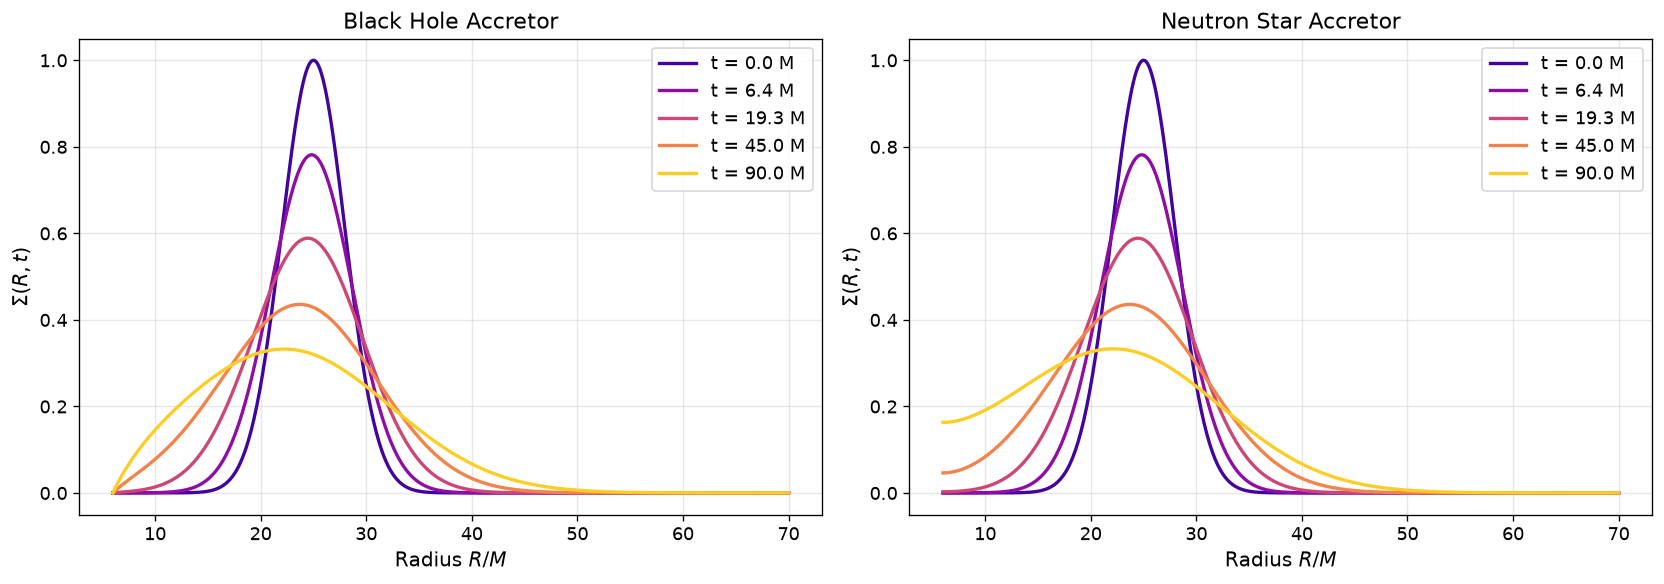

In [9]:
# simulate both compact objects
R_bh, t_bh, Sigma_bh = solve_accretion_disk(nu=0.15, is_black_hole=True)
R_ns, t_ns, Sigma_ns = solve_accretion_disk(nu=0.15, is_black_hole=False)

# plot side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

time_snapshots = [0, 50, 150, 350, 700]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(time_snapshots)))

# black hole profiles
for idx, c in zip(time_snapshots, colors):
    ax1.plot(R_bh, Sigma_bh[idx, :], label=f't = {t_bh[idx]:.1f} M', color=c, lw=2)
ax1.set_xlabel('Radius $R / M$')
ax1.set_ylabel('$\Sigma(R, t)$')
ax1.set_title(r'Black Hole Accretor')
ax1.grid(True, alpha=0.3)
ax1.legend()

# neutron star profiles
for idx, c in zip(time_snapshots, colors):
    ax2.plot(R_ns, Sigma_ns[idx, :], label=f't = {t_ns[idx]:.1f} M', color=c, lw=2)
ax2.set_xlabel('Radius $R / M$')
ax2.set_ylabel('$\Sigma(R, t)$')
ax2.set_title(r'Neutron Star Accretor')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
def classify_compact_object(Sigma, R_grid, t_grid, threshold=1e-3):
    """
    Classifies the accretor as a BH or NS.
    
    Physical Principle:
    - Black Hole (BH): Zero-torque ISCO sink -> Sigma(R_in, t) = 0 .
    - Neutron Star (NS): Solid surface boundary layer -> Sigma(R_in, t) > 0 .
    """
    R_in = R_grid[0]
    inner_density = Sigma[:, 0]  # srface density at R_in for each t
    max_inner_density = np.max(inner_density)
    mean_inner_density = np.mean(inner_density)
    
    #  non-zero density at R_in means a solid surface boundary layer
    if max_inner_density > threshold:
        obj_type = "Neutron Star (NS)"
    else:
        obj_type = "Black Hole (BH)"
        
    return {
        "type": obj_type,
        "max_inner_density": max_inner_density,
        "mean_inner_density": mean_inner_density,
        "inner_density_profile": inner_density
    }

bh_results = classify_compact_object(Sigma_bh, R_bh, t_bh)
ns_results = classify_compact_object(Sigma_ns, R_ns, t_ns)

print("C.O. DISCRIMINATION FROM DISK DENSITIES")
for name, res in [("Black Hole Simulation", bh_results), ("Neutron Star Simulation", ns_results)]:
    print(f"\n{name}:")
    print(f"Inferred Object Type : {res['type']}")
    print(f"Max Density at R_in  : {res['max_inner_density']:.5f}")
    print(f"Mean Density at R_in : {res['mean_inner_density']:.5f}")


C.O. DISCRIMINATION FROM DISK DENSITIES

Black Hole Simulation:
Inferred Object Type : Black Hole (BH)
Max Density at R_in  : 0.00000
Mean Density at R_in : 0.00000

Neutron Star Simulation:
Inferred Object Type : Neutron Star (NS)
Max Density at R_in  : 0.16296
Mean Density at R_in : 0.05922


## Step 5: Noise Robustness

Observational data is subject to instrumental noise. Below is a benchmark of robustness comparing SINDy and WSINDy on native cylindrical data $(R, t)$ across Gaussian noise levels $\eta $ from 0 to 50%.

In [ ]:
# noise levels and rounds to evaluate
noise_levels = [0.0,0.005, 0.01, 0.02, 0.05, 0.075, 0.10, 0.15, 0.20,0.25,0.3,0.35,0.4,0.45,0.5]
n_rounds = 5
nu_true = 0.15

# reference
c_diff_true = 3.0 * nu_true

np.random.seed(42)
std_Sigma = np.std(Sigma_data)

errors_strong = np.zeros((len(noise_levels), n_rounds))
errors_weak = np.zeros((len(noise_levels), n_rounds))

nu_strong = np.zeros((len(noise_levels), n_rounds))
nu_weak = np.zeros((len(noise_levels), n_rounds))

rel_err_nu_strong = np.zeros((len(noise_levels), n_rounds))
rel_err_nu_weak = np.zeros((len(noise_levels), n_rounds))

complexity_strong = np.zeros((len(noise_levels), n_rounds))
complexity_weak = np.zeros((len(noise_levels), n_rounds))
#threshold=0.1/0.4 for parsimony
for i, eta in enumerate(noise_levels):
    for r in range(n_rounds):
        noise = np.random.normal(0, eta * std_Sigma, size=Sigma_data.shape) if eta > 0 else np.zeros_like(Sigma_data)
        Sigma_noisy = Sigma_data + noise
        u_noisy = Sigma_noisy.T[:, :, np.newaxis]
        
        # SINDy on noisy data 
        opt_s = ps.STLSQ(threshold=0.4, alpha=0.05, max_iter=500, normalize_columns=True)
        m_s = ps.SINDy(feature_library=pde_lib_strong, optimizer=opt_s)
        m_s.fit(u_noisy, t=t_grid, feature_names=['Sigma'])
        coeffs_s = m_s.coefficients()[0]
        names_s = m_s.get_feature_names()
        c_diff_s = coeffs_s[names_s.index('Sigma_11')] if 'Sigma_11' in names_s else 0.0
        err_s = abs(c_diff_s - c_diff_true) / c_diff_true
        errors_strong[i, r] = min(err_s, 1.0)
        nu_s = c_diff_s / 3.0
        nu_strong[i, r] = nu_s
        rel_err_nu_strong[i, r] = abs(nu_s - nu_true) / nu_true * 100.0
        complexity_strong[i, r] = int(np.sum(np.abs(coeffs_s) > 1e-4))
        
        # WSINDy on noisy data
        opt_w = ps.STLSQ(threshold=0.1, alpha=0.05, max_iter=500, normalize_columns=True)
        m_w = ps.SINDy(feature_library=weak_lib, optimizer=opt_w)
        m_w.fit(u_noisy, t=t_grid, feature_names=['Sigma'])
        coeffs_w = m_w.coefficients()[0]
        names_w = m_w.get_feature_names()
        c_diff_w = coeffs_w[names_w.index('Sigma_11')] if 'Sigma_11' in names_w else 0.0
        err_w = abs(c_diff_w - c_diff_true) / c_diff_true
        errors_weak[i, r] = min(err_w, 1.0)
        nu_w = c_diff_w / 3.0
        nu_weak[i, r] = nu_w
        rel_err_nu_weak[i, r] = abs(nu_w - nu_true) / nu_true * 100.0
        complexity_weak[i, r] = int(np.sum(np.abs(coeffs_w) > 1e-4))

# mean and std
mean_s = np.mean(errors_strong, axis=1) * 100
std_s = np.std(errors_strong, axis=1) * 100
mean_w = np.mean(errors_weak, axis=1) * 100
std_w = np.std(errors_weak, axis=1) * 100

nu_w_mean = np.mean(nu_weak, axis=1)
nu_w_std = np.std(nu_weak, axis=1)

# plot noise benchmark
fig, axes = plt.subplots(2, 1, figsize=(6, 8))
pct_noise = [eta * 100 for eta in noise_levels]

axes[0].errorbar(pct_noise, mean_s, yerr=std_s, fmt='o--', color='crimson', lw=2, ms=6, capsize=3, label='SINDy')
axes[0].errorbar(pct_noise, mean_w, yerr=std_w, fmt='s-', color='dodgerblue', lw=2, ms=6, capsize=3, label='WSINDy')
axes[0].set_xlabel(r'Noise Level $\eta$ (%)')
axes[0].set_ylabel('Parameter Discovery Error (%)')
axes[0].set_title('Noise Robustness Benchmark')
axes[0].set_yscale('symlog')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].errorbar(pct_noise, nu_w_mean, yerr=nu_w_std, fmt='s-', color='dodgerblue',
                 lw=2.2, ms=7, capsize=4, elinewidth=1.8, capthick=1.5,
                 label=r'WSINDy Retrieved $\nu \pm 1\sigma$')


axes[1].set_xlabel(r'$\eta$ (%)')
axes[1].set_ylabel(r'$\nu$')
axes[1].set_title(r'WSINDy Retrieved $\nu$ vs Noise')
axes[1].set_ylim(0.08, 0.160)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='lower left', frameon=True)

plt.tight_layout()
plt.show()


### Step 5.1: Spatiotemporal Reconstruction under Severe Observational Noise

To visually validate the physical fidelity of the equations discovered under noise, i simulated the forward spatiotemporal evolution $\Sigma(R, t)$ directly from the SINDy and WSINDy models identified at $\eta = 20\%$ noise.

Reconstruction relative error: WSINDy = 4.87%, SINDy = 37.33%


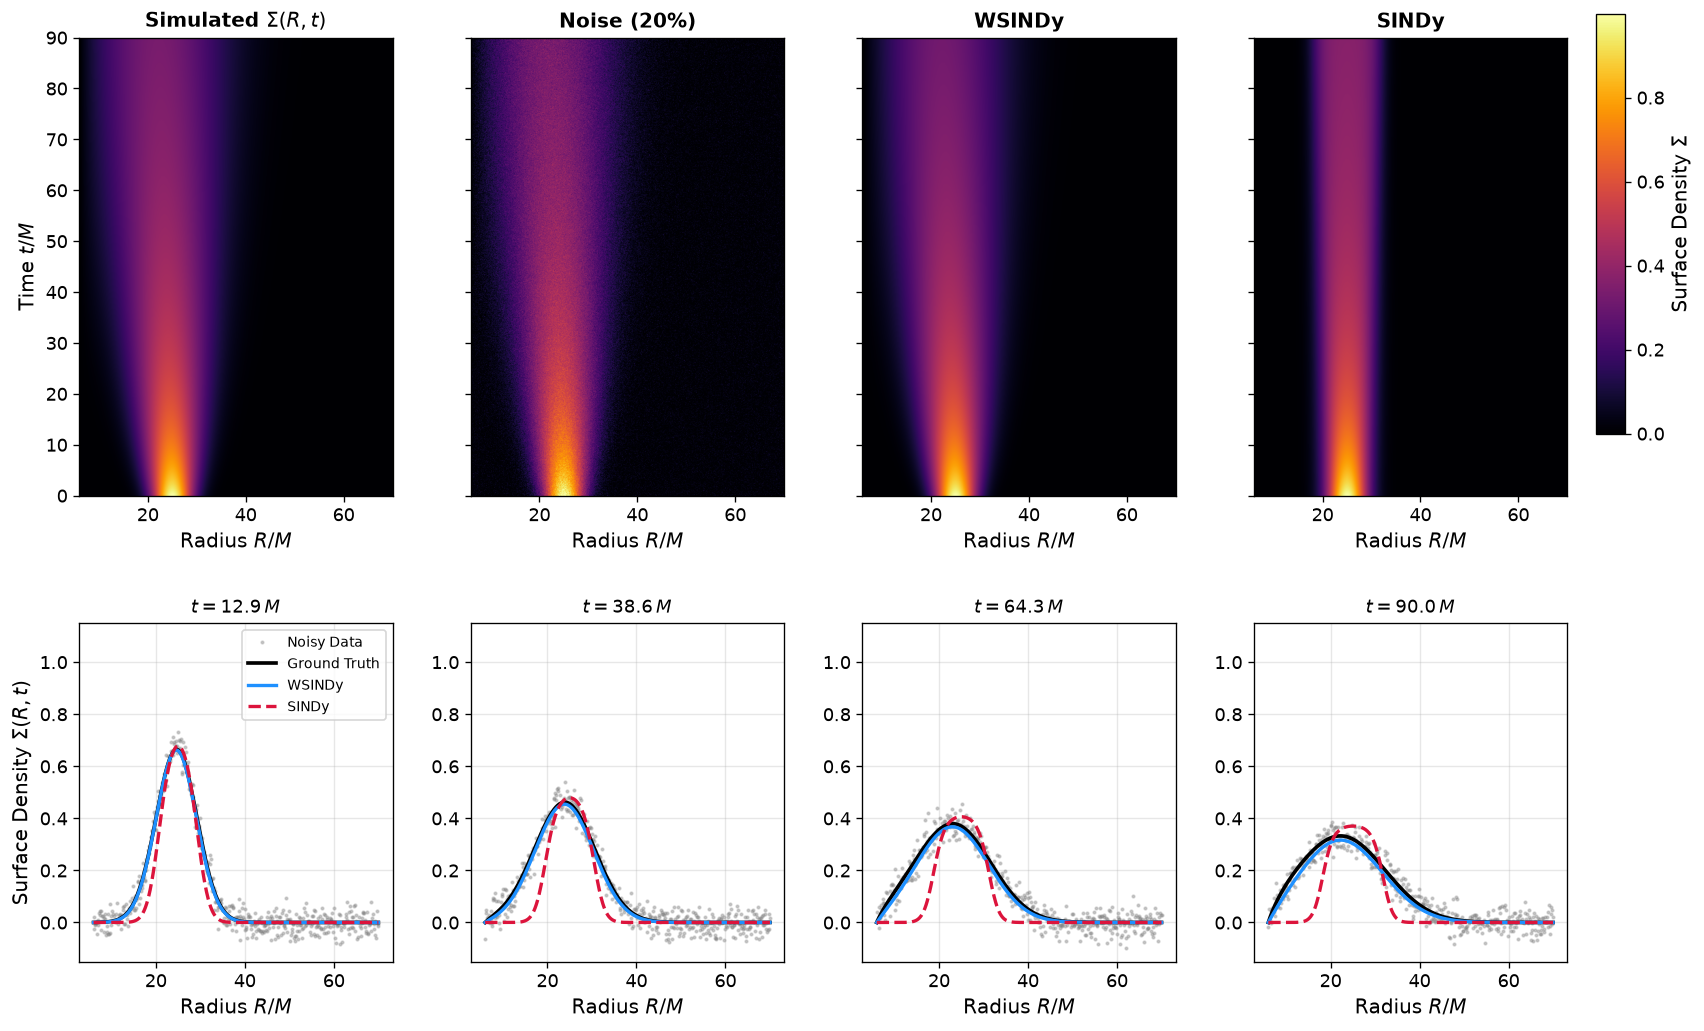

In [ ]:
# fit sindy and wsindy models on 20% noisy data
np.random.seed(42)
eta_eval = 0.20
noise_20 = np.random.normal(0, eta_eval * np.std(Sigma_data), size=Sigma_data.shape)
Sigma_noisy_20 = Sigma_data + noise_20
u_noisy_20 = Sigma_noisy_20.T[:, :, np.newaxis]

opt_s_20 = ps.STLSQ(threshold=0.4, alpha=0.05, max_iter=2000, normalize_columns=True)
m_s_20 = ps.SINDy(feature_library=pde_lib_strong, optimizer=opt_s_20)
m_s_20.fit(u_noisy_20, t=t_grid, feature_names=['Sigma'])

opt_w_20 = ps.STLSQ(threshold=0.1, alpha=0.05, max_iter=2000, normalize_columns=True)
m_w_20 = ps.SINDy(feature_library=weak_lib, optimizer=opt_w_20)
m_w_20.fit(u_noisy_20, t=t_grid, feature_names=['Sigma'])

def simulate_discovered_cylindrical(model, R_grid, t_grid, init_Sigma):
    names = model.get_feature_names()
    coeffs = model.coefficients()[0]
    coef_dict = dict(zip(names, coeffs))
    
    dR = R_grid[1] - R_grid[0]
    dt = t_grid[1] - t_grid[0]
    N_t = len(t_grid)
    N_R = len(R_grid)
    
    n_substeps = 40
    dt_sub = dt / n_substeps
    
    Sigma_sim = np.zeros((N_t, N_R))
    curr = init_Sigma.copy()
    Sigma_sim[0, :] = curr.copy()
    
    for n in range(N_t - 1):
        for _ in range(n_substeps):
            dSigma_dt = np.zeros_like(curr)
            for name, c in coef_dict.items():
                if abs(c) < 1e-5:
                    continue
                term_val = np.ones_like(curr)
                if 'Sigma_11' in name:
                    d2 = np.gradient(np.gradient(curr, dR), dR)
                    term_val *= d2
                elif 'Sigma_1' in name:
                    d1 = np.gradient(curr, dR)
                    term_val *= d1
                if 'Sigma^3' in name:
                    term_val *= curr**3
                elif 'Sigma^2' in name:
                    term_val *= curr**2
                elif 'Sigma' in name and not ('Sigma_1' in name and 'SigmaSigma' not in name):
                    if name.startswith('Sigma') and not name.startswith('Sigma_'):
                        term_val *= curr
                dSigma_dt += c * term_val
            curr += dt_sub * dSigma_dt
            curr[0] = 0.0   # ISCO sink boundary
            curr[-1] = 0.0  # outer boundary
            curr = np.maximum(curr, 0.0)
            if np.any(np.isnan(curr)) or np.any(np.isinf(curr)):
                break
        Sigma_sim[n+1, :] = curr.copy()
    return Sigma_sim

init_profile = Sigma_data[0, :].copy()
Sigma_rec_wsindy = simulate_discovered_cylindrical(m_w_20, R_grid, t_grid, init_profile)
Sigma_rec_sindy = simulate_discovered_cylindrical(m_s_20, R_grid, t_grid, init_profile)

rel_err_wsindy = np.linalg.norm(Sigma_rec_wsindy - Sigma_data) / np.linalg.norm(Sigma_data)
rel_err_sindy = np.linalg.norm(Sigma_rec_sindy - Sigma_data) / np.linalg.norm(Sigma_data)

print(f'Reconstruction relative error: WSINDy = {rel_err_wsindy*100:.2f}%, SINDy = {rel_err_sindy*100:.2f}%')

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 4, height_ratios=[1.15, 0.85], hspace=0.32, wspace=0.25)
vmax = np.max(Sigma_data)

ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(Sigma_data, aspect='auto', origin='lower',
                extent=[R_grid[0], R_grid[-1], t_grid[0], t_grid[-1]],
                cmap='inferno', vmin=0, vmax=vmax)
ax0.set_title(r'Simulated $\Sigma(R, t)$', fontsize=12, fontweight='bold')
ax0.set_xlabel(r'Radius $R / M$')
ax0.set_ylabel(r'Time $t / M$')

ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)
im1 = ax1.imshow(Sigma_noisy_20, aspect='auto', origin='lower',
                extent=[R_grid[0], R_grid[-1], t_grid[0], t_grid[-1]],
                cmap='inferno', vmin=0, vmax=vmax)
ax1.set_title(rf'Noise ({100*eta_eval:.0f}%)', fontsize=12, fontweight='bold')
ax1.set_xlabel(r'Radius $R / M$')
ax1.tick_params(labelleft=False)

ax2 = fig.add_subplot(gs[0, 2], sharey=ax0)
im2 = ax2.imshow(Sigma_rec_wsindy, aspect='auto', origin='lower',
                extent=[R_grid[0], R_grid[-1], t_grid[0], t_grid[-1]],
                cmap='inferno', vmin=0, vmax=vmax)
ax2.set_title(f'WSINDy', fontsize=12, fontweight='bold')
ax2.set_xlabel(r'Radius $R / M$')
ax2.tick_params(labelleft=False)

ax3 = fig.add_subplot(gs[0, 3], sharey=ax0)
im3 = ax3.imshow(Sigma_rec_sindy, aspect='auto', origin='lower',
                extent=[R_grid[0], R_grid[-1], t_grid[0], t_grid[-1]],
                cmap='inferno', vmin=0, vmax=vmax)
ax3.set_title(f'SINDy', fontsize=12, fontweight='bold')
ax3.set_xlabel(r'Radius $R / M$')
ax3.tick_params(labelleft=False)

cbar_ax = fig.add_axes([0.915, 0.55, 0.015, 0.35])
fig.colorbar(im0, cax=cbar_ax, label=r'Surface Density $\Sigma$')

snap_indices = [100, 300, 500, 700]
for col_idx, snap in enumerate(snap_indices):
    ax_snap = fig.add_subplot(gs[1, col_idx])
    t_val = t_grid[snap]
    ax_snap.plot(R_grid, Sigma_noisy_20[snap, :], '.', color='gray', alpha=0.35, ms=3, label=r'Noisy Data')
    ax_snap.plot(R_grid, Sigma_data[snap, :], 'k-', lw=2.2, label='Ground Truth')
    ax_snap.plot(R_grid, Sigma_rec_wsindy[snap, :], '-', color='dodgerblue', lw=2.0, label='WSINDy')
    ax_snap.plot(R_grid, Sigma_rec_sindy[snap, :], '--', color='crimson', lw=2.0, label='SINDy')
    ax_snap.set_title(f'$t = {t_val:.1f}\,M$', fontsize=11, fontweight='bold')
    ax_snap.set_xlabel(r'Radius $R / M$')
    if col_idx == 0:
        ax_snap.set_ylabel(r'Surface Density $\Sigma(R, t)$')
        ax_snap.legend(fontsize=8.5, loc='upper right')
    ax_snap.grid(True, alpha=0.3)
    ax_snap.set_ylim(-0.15, 1.15)
plt.tight_layout()
plt.show()


### Step 5.2: Summary of Findings 

In [ ]:
# parsimony enforced w/ threshold = 0.1


print(f"{'Noise':<7} | {'SINDy nu':<18} | {'SINDy Rel Err (%)':<20} | {'SINDy k':<8} | {'WSINDy nu':<18} | {'WSINDy Rel Err (%)':<20} | {'WSINDy k':<8}")
print("-" * 125)

for i, eta in enumerate(noise_levels):
    pct = eta * 100
    s_nu_m, s_nu_s = np.mean(nu_strong[i, :]), np.std(nu_strong[i, :])
    s_err_m, s_err_s = np.mean(rel_err_nu_strong[i, :]), np.std(rel_err_nu_strong[i, :])
    s_k_m = np.mean(complexity_strong[i, :])
    
    w_nu_m, w_nu_s = np.mean(nu_weak[i, :]), np.std(nu_weak[i, :])
    w_err_m, w_err_s = np.mean(rel_err_nu_weak[i, :]), np.std(rel_err_nu_weak[i, :])
    w_k_m = np.mean(complexity_weak[i, :])
    
    # Text format
    s_err_txt = f"{s_err_m:>5.2f}% ± {s_err_s:>4.2f}%" 
    w_err_txt = f"{w_err_m:>5.2f}% ± {w_err_s:>4.2f}%"
    print(f"{pct:>5.1f}% | {s_nu_m:.4f} ± {s_nu_s:.4f} | {s_err_txt:<20} | {s_k_m:>7.1f} | {w_nu_m:.4f} ± {w_nu_s:.4f} | {w_err_txt:<20} | {w_k_m:>8.1f} ")
    


Noise   | SINDy nu           | SINDy Rel Err (%)    | SINDy k  | WSINDy nu          | WSINDy Rel Err (%)   | WSINDy k
-----------------------------------------------------------------------------------------------------------------------------
  0.0% | 0.1493 ± 0.0000 |  0.44% ± 0.00%       |     2.0 | 0.1526 ± 0.0000 |  1.76% ± 0.00%       |      2.0 
  0.5% | 0.0000 ± 0.0000 | 100.00% ± 0.00%      |     3.0 | 0.1526 ± 0.0000 |  1.76% ± 0.02%       |      2.0 
  1.0% | 0.0000 ± 0.0000 | 100.00% ± 0.00%      |     3.0 | 0.1527 ± 0.0001 |  1.77% ± 0.04%       |      2.0 
  2.0% | 0.0000 ± 0.0000 | 100.00% ± 0.00%      |     3.0 | 0.1526 ± 0.0002 |  1.71% ± 0.12%       |      2.0 
  5.0% | 0.0000 ± 0.0000 | 100.00% ± 0.00%      |     3.0 | 0.1524 ± 0.0006 |  1.60% ± 0.38%       |      2.0 
  7.5% | 0.0000 ± 0.0000 | 100.00% ± 0.00%      |     3.0 | 0.1520 ± 0.0005 |  1.36% ± 0.30%       |      2.0 
 10.0% | 0.0000 ± 0.0000 | 100.00% ± 0.00%      |     3.0 | 0.1515 ± 0.0009 |  1.00% ± 0.5